<a href="https://colab.research.google.com/github/GustavoABrandao/Projeto---IA-Facens/blob/main/Projeto%20Big%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [195]:
# Importando bibliotecas necessárias
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import expr
from pyspark.sql.functions import col, regexp_extract
from pyspark.sql.functions import expr, current_date, year as spark_year
import matplotlib.pyplot as plt
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

spark = SparkSession.builder \
    .appName("PySpark Docker Example") \
    .getOrCreate()

In [196]:
dataframe = spark.read.csv("/content/vehicles.csv", header=True, inferSchema=True)
num_linhas = dataframe.count()
print(f"Número de linhas no DataFrame: {num_linhas}")

Número de linhas no DataFrame: 441802


In [197]:
dataframe.show(50)

+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|        id|                 url|              region|          region_url|price|year|manufacturer|               model|condition|  cylinders| fuel|odometer|title_status|transmission|              VIN|drive|     size|  type|paint_color|           image_url|         description|county|state|    lat|      long|        posting_date|
+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|722

In [209]:
df = dataframe

# Regex mais flexível: ignora o que não for número/ponto/sinal de menos
# Removemos o sinal de negativo de colunas que não podem ser negativas (preço, ano, km)
df = df.withColumn(
    "year",
    expr("try_cast(regexp_replace(year, '[^0-9]', '') as double)")
)

df = df.withColumn(
    "price",
    expr("try_cast(regexp_replace(price, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "odometer",
    expr("try_cast(regexp_replace(odometer, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "lat",
    expr("try_cast(regexp_replace(lat, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "long",
    expr("try_cast(regexp_replace(long, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "car_age",
    spark_year(current_date()) - col("year")
)
# Remoção de colunas
df = df.drop(
    "id", "url", "region_url", "VIN",
    "image_url", "description", "county",
    "posting_date", "size"
)

In [199]:
# =========================
# 2. DROP E FILTROS (MENOS AGRESSIVO)
# =========================

# DICA: Removi lat e long do dropna. Se não tiver localização, a gente mantém o carro!
df = df.dropna(subset=["price", "year", "odometer"])

# Filtros de sanidade
df = df.filter(
    (col("price") >= 100.0) & (col("price") < 1000000.0) &
    (col("year") > 2001.0) & (col("year") <= 2026.0)
)

# VERIFICAÇÃO INTERMEDIÁRIA
contagem = df.count()
print(f"Registros após limpeza inicial: {contagem}")

if contagem > 0:
    # 3. CACHE E ESTATÍSTICA
    df.cache()

    for c in ["price", "odometer"]:
        # Verificamos se há dados suficientes para calcular quantis
        quantis = df.approxQuantile(c, [0.10, 0.90], 0.05)
        if len(quantis) == 2:
            q_low, q_high = quantis[0], quantis[1]
            df = df.filter((col(c) >= q_low) & (col(c) <= q_high))
            print(f"Filtro aplicado em {c}: {q_low} até {q_high}")

    print(f"Registros finais: {df.count()}")
else:
    print("ERRO: O filtro deletou todos os dados! Verifique as colunas de entrada.")
    df.show(5) # Mostra o que restou para você entender o problema

Registros após limpeza inicial: 355170
Filtro aplicado em price: 4499.0 até 34995.0
Filtro aplicado em odometer: 20624.0 até 154690.0
Registros finais: 201821


In [200]:
# =========================
# 3. Colunas categóricas
# =========================

# One-hot (nominais)
categorical_cols = [
    "region", "manufacturer", "fuel", "transmission",
    "drive", "type", "paint_color", "state", "title_status"
]

# StringIndexer (ordinal ou alta cardinalidade)
index_cols = ["condition", "model"]


In [201]:
# =========================
# 4. Criar stages
# =========================
stages = []

# Index + OneHot para categóricas nominais
for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    encoder = OneHotEncoder(
        inputCol=col_name + "_index",
        outputCol=col_name + "_onehot",
        dropLast=True
    )

    stages += [indexer, encoder]

# Apenas index para ordinal/alta cardinalidade
for col_name in index_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    stages.append(indexer)



In [202]:
# =========================
# 5. Pipeline
# =========================
pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
df_prepared = model.transform(df)
df_prepared.createOrReplaceTempView("cars_prepared")


In [203]:
features_sql = spark.sql("""
SELECT *
FROM cars_prepared
LIMIT 20
""")

features_sql.show()


+------+-------+------+------------+--------------------+---------+-----------+------+--------+------------+------------+-----+--------+-----------+-----+---------+---------+-------+------------+-----------------+------------------+-------------------+----------+-------------+------------------+-------------------+-----------+-------------+----------+---------------+-----------------+------------------+-----------+-----------------+------------------+-------------------+---------------+-----------+
|region|  price|  year|manufacturer|               model|condition|  cylinders|  fuel|odometer|title_status|transmission|drive|    type|paint_color|state|      lat|     long|car_age|region_index|    region_onehot|manufacturer_index|manufacturer_onehot|fuel_index|  fuel_onehot|transmission_index|transmission_onehot|drive_index| drive_onehot|type_index|    type_onehot|paint_color_index|paint_color_onehot|state_index|     state_onehot|title_status_index|title_status_onehot|condition_index|model

In [204]:
df_prepared.createOrReplaceTempView("view_treino")

# Selecionamos as versões para o modelo
df_pre_treino = spark.sql("""
    SELECT
        price,
        car_age,
        odometer,
        lat,
        long,
        region_onehot,
        manufacturer_onehot,
        fuel_onehot,
        transmission_index,
        drive_onehot,
        type_onehot,
        paint_color_onehot,
        state_onehot,
        title_status_onehot,
        condition_index,
        model_index
    FROM view_treino
""")

df_pre_treino.show(50)


+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|  price|car_age|odometer|      lat|      long|    region_onehot|manufacturer_onehot|  fuel_onehot|transmission_index| drive_onehot|    type_onehot|paint_color_onehot|     state_onehot|title_status_onehot|condition_index|model_index|
+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|33590.0|   12.0| 57923.0|    32.59|    -85.48|(404,[337],[1.0])|     (38,[8],[1.0])|(5,[0],[1.0])|               1.0|    (3,[],[])| (13,[2],[1.0])|    (12,[0],[1.0])|(6300,[29],[1.0])|      (6,[0],[1.0])|            1.0|      186.0|
|22590.0|   16.0| 71229.0|    32.59|    -85.48|(404,[337],[1.0])

In [206]:
import numpy as np
import matplotlib.pyplot as plt

data_norm = []

cols = ["price", "odometer", "car_age"]

for c in cols:
    sample = df_final_treino.select(c) \
        .dropna() \
        .sample(False, 0.05, seed=42) \
        .rdd.map(lambda x: x[0]) \
        .collect()

    sample = np.array(sample)

    std = sample.std()

    if std != 0:
        sample = (sample - sample.mean()) / std
    else:
        sample = sample - sample.mean()  # evita divisão por zero

    data_norm.append(sample)

plt.figure(figsize=(8,5))
plt.boxplot(data_norm)
plt.xticks(range(1, len(cols)+1), cols)
plt.title("Boxplot normalizado")
plt.ylabel("Valores normalizados")
plt.show()

{"ts": "2026-05-02 20:26:41.570", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `car_age` cannot be resolved. Did you mean one of the following? [`lat`, `long`, `price`, `year`, `odometer`]. SQLSTATE: 42703", "context": {"file": "java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o7058.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `car_age` cannot be resolved. Did you mean one of the following? [`lat`, `long`, `price`, `year`, `odometer`]. SQLSTATE: 42703;\n'Project ['car_age]\n+- Project [price#35831, year#35832, odometer#35833, lat#35834, long#35835, region_onehot#42625, manufacturer_onehot#42643

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `car_age` cannot be resolved. Did you mean one of the following? [`lat`, `long`, `price`, `year`, `odometer`]. SQLSTATE: 42703;
'Project ['car_age]
+- Project [price#35831, year#35832, odometer#35833, lat#35834, long#35835, region_onehot#42625, manufacturer_onehot#42643, fuel_onehot#42661, transmission_index#42671, drive_onehot#42697, type_onehot#42715, paint_color_onehot#42733, state_onehot#42751, title_status_onehot#42769, condition_index#42779, model_index#42786]
   +- SubqueryAlias view_treino
      +- View (`view_treino`, [region#820, price#35831, year#35832, manufacturer#824, model#825, condition#826, cylinders#827, fuel#828, odometer#35833, title_status#830, transmission#831, drive#833, type#835, paint_color#836, state#840, lat#35834, long#35835, region_index#42617, region_onehot#42625, manufacturer_index#42635, manufacturer_onehot#42643, fuel_index#42653, fuel_onehot#42661

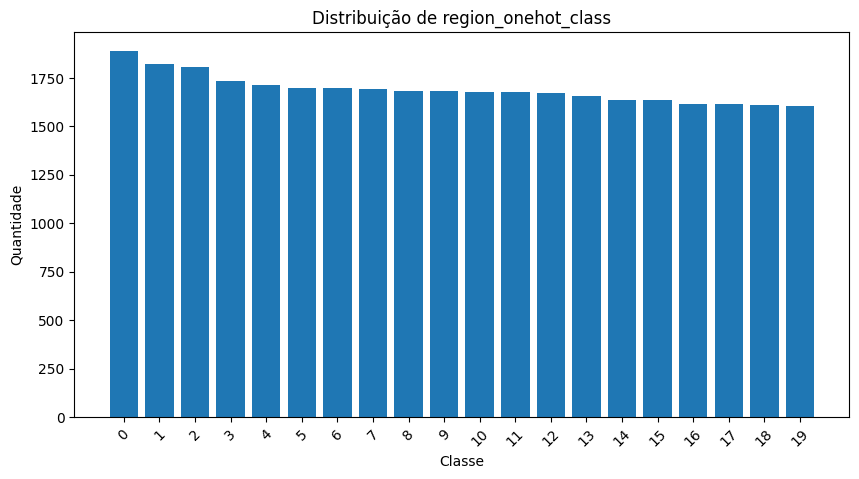

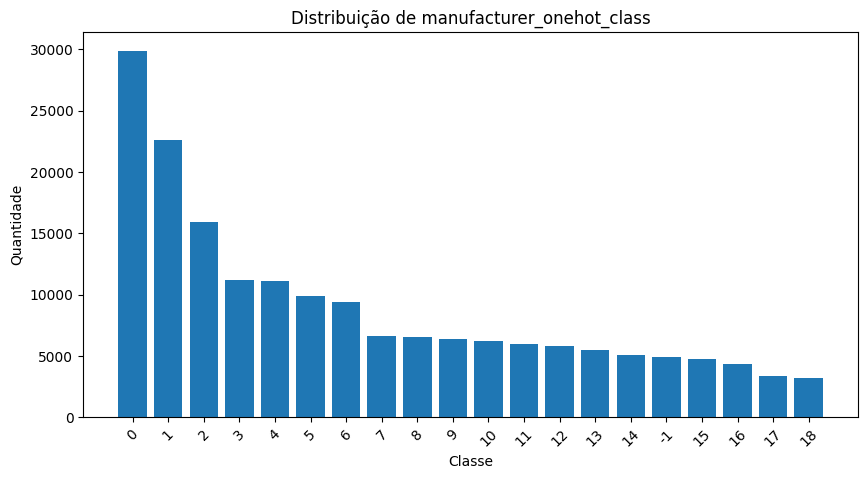

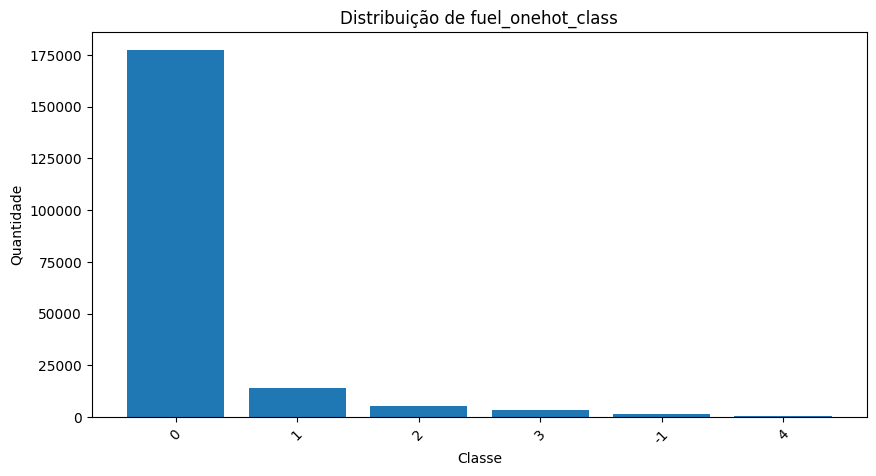

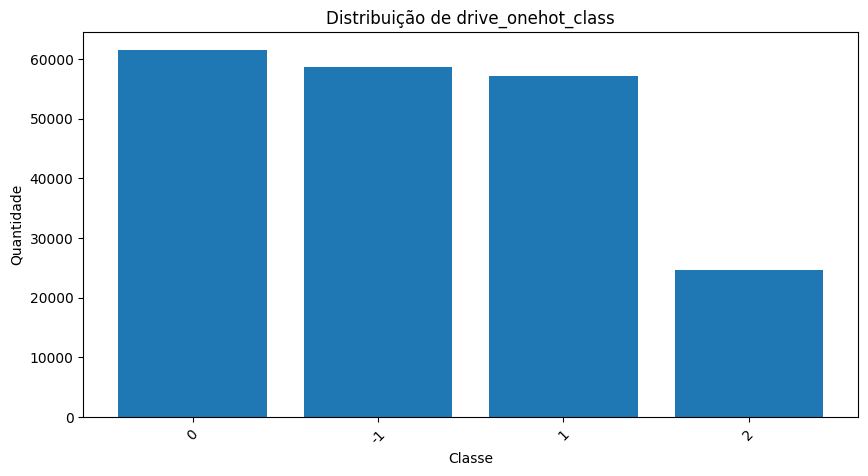

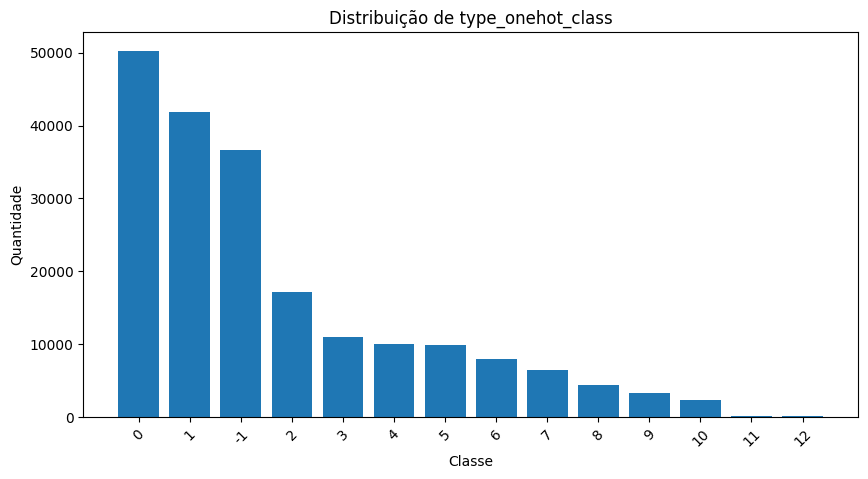

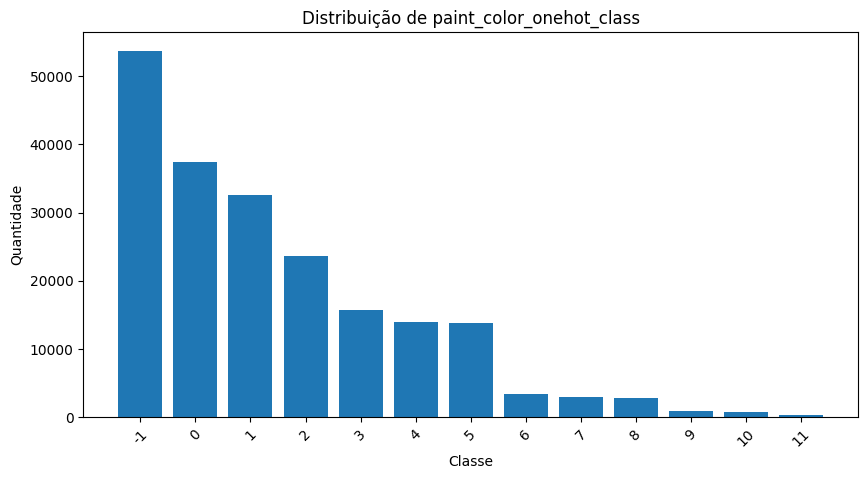

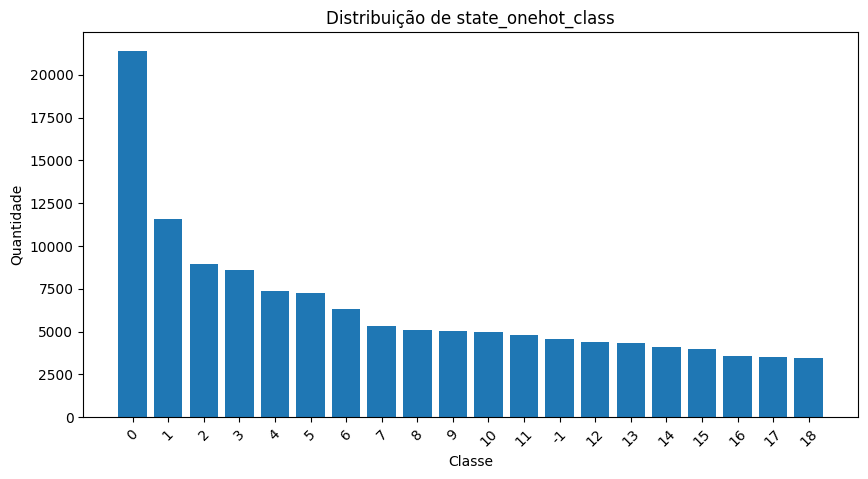

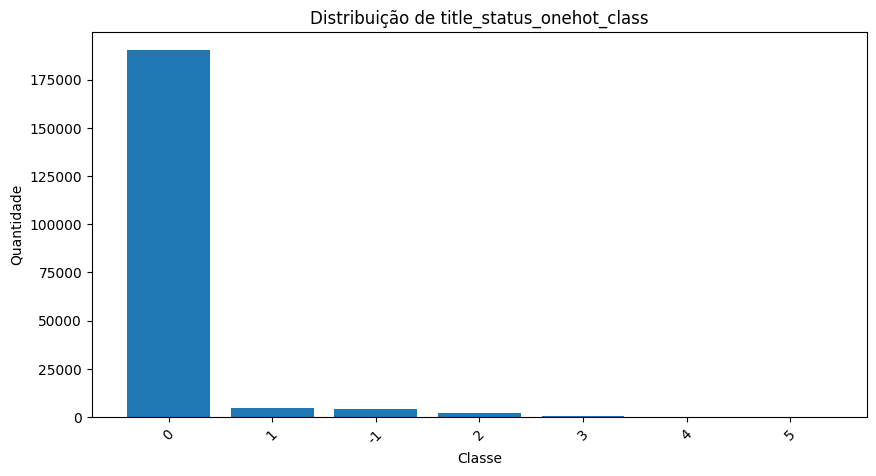

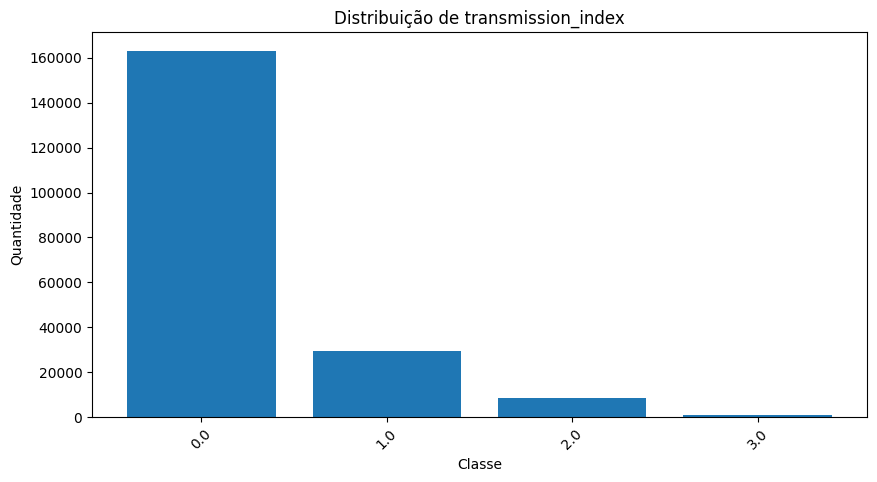

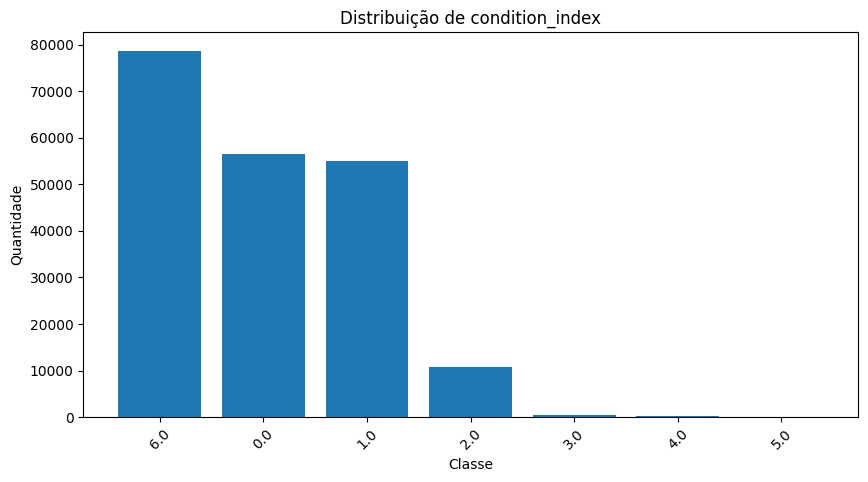

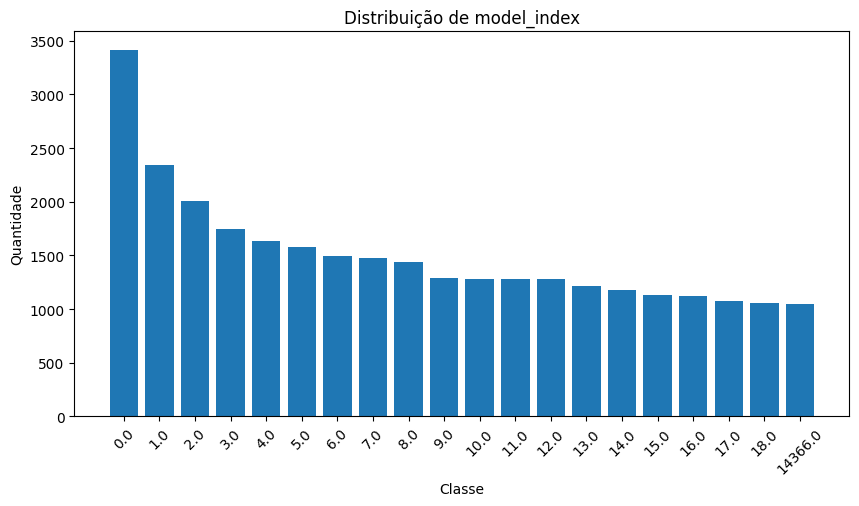

In [208]:

# Converte vetor one-hot para índice da posição ativa
def onehot_to_index(v):
    if v is None:
        return None
    arr = v.toArray()
    if arr.sum() == 0:
        return -1
    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

onehot_cols = [
    "region_onehot",
    "manufacturer_onehot",
    "fuel_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "state_onehot",
    "title_status_onehot"
]

index_cols = [
    "transmission_index",
    "condition_index",
    "model_index"
]

df_plot = df_pre_treino

for c in onehot_cols:
    df_plot = df_plot.withColumn(c + "_class", onehot_to_index_udf(col(c)))

plot_cols = [c + "_class" for c in onehot_cols] + index_cols

for c in plot_cols:
    data = df_plot.groupBy(c) \
        .count() \
        .orderBy("count", ascending=False) \
        .limit(20) \
        .collect()

    x = [str(row[c]) for row in data]
    y = [row["count"] for row in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Distribuição de {c}")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.show()

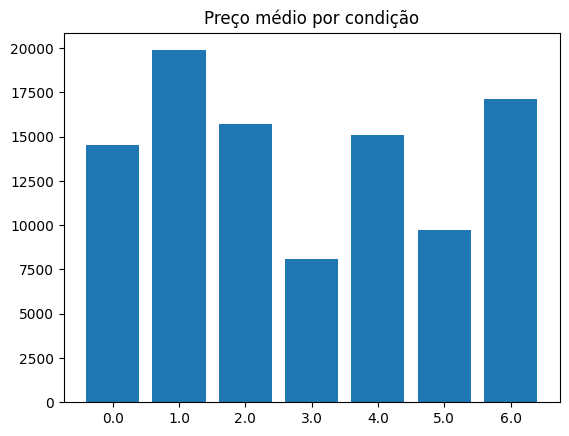

In [207]:
data = df_pre_treino.groupBy("condition_index") \
    .agg({"price": "avg"}) \
    .orderBy("condition_index") \
    .collect()

x = [str(row["condition_index"]) for row in data]
y = [row["avg(price)"] for row in data]

plt.bar(x, y)
plt.title("Preço médio por condição")
plt.show()